### Experiment 6 Binary Classification on Breast Cancer using Bagging, Boosting and Stacking
#### Hemnath D - 3122247001022 (MTech Integrated CSE)

Aim: To perform binary classification on the Wisconsin Diagnostic Breast Cancer (WDBC) dataset using Bagging, Boosting (AdaBoost and Gradient Boosting), and Stacking ensemble methods, including hyperparameter tuning with 5-fold cross-validation, feature importance, ROC analysis, and a comparative study of all models

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

RNG = 42
DPI = 600
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


##### Loading the dataset
Reading the raw UCI wdbc.data file and assigning feature column names based on wdbc.names

In [2]:

def load_wdbc(path="wdbc.data"):
    base_stats = ["radius", "texture", "perimeter", "area", "smoothness",
                  "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]
    cols = ["id", "diagnosis"]
    for suffix in ["mean", "se", "worst"]:
        cols += [f"{b}_{suffix}" for b in base_stats]
    df = pd.read_csv(path, header=None, names=cols)
    return df


In [3]:

df = load_wdbc("wdbc.data")
print(df.shape)
print(df["diagnosis"].value_counts())
print("missing values:", df.isnull().sum().sum())
df.head()


(569, 32)
diagnosis
B    357
M    212
Name: count, dtype: int64
missing values: 0


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


##### Dataset overview
Verifying dataset dimensions (569 samples, 30 numeric features), class balance, and checking for missing or duplicate records

In [4]:
dataset_summary = pd.DataFrame({
    "Property": ["Number of samples", "Number of features", "Number of classes",
                 "Benign samples (class 0)", "Malignant samples (class 1)",
                 "Missing values", "Duplicate rows"],
    "Value": [df.shape[0], df.shape[1] - 2, 2,
              int((df["diagnosis"] == "B").sum()), int((df["diagnosis"] == "M").sum()),
              int(df.isnull().sum().sum()), int(df.drop(columns=["id"]).duplicated().sum())],
})
dataset_summary

,Property,Value
0,Number of samples,569
1,Number of features,30
2,Number of classes,2
3,Benign samples (class 0),357
4,Malignant samples (class 1),212
5,Missing values,0
6,Duplicate rows,0


##### Exploratory data analysis: class distribution
Checking class distribution between benign (357 samples, ~62.7%) and malignant (212 samples, ~37.3%)

In [5]:

def plot_class_distribution(df, fname="fig1_class_distribution.png"):
    counts = df["diagnosis"].value_counts()
    labels = {"B": "Benign", "M": "Malignant"}
    fig, ax = plt.subplots(figsize=(6, 4.5))
    bars = ax.bar([labels[c] for c in counts.index], counts.values,
                  color=["#4C72B0", "#C44E52"], edgecolor="black", linewidth=0.7)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 4, str(int(b.get_height())),
                ha="center", fontsize=11)
    ax.set_ylabel("Number of samples")
    ax.set_title("Class distribution, WDBC dataset")
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


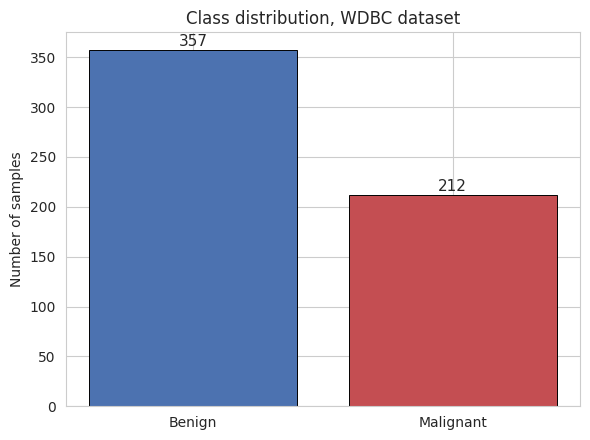

In [6]:

plot_class_distribution(df)


##### Class-wise descriptive statistics
Comparing mean values and standard deviations between benign and malignant classes for the 10 mean feature measurements

In [7]:
mean_feats = [c for c in df.columns if c.endswith("_mean")]
class_stats = df.groupby("diagnosis")[mean_feats].mean().T.round(2)
class_stats.columns = ["Benign (mean)", "Malignant (mean)"]
class_stats["Malignant / Benign ratio"] = (class_stats["Malignant (mean)"] / class_stats["Benign (mean)"]).round(2)
class_stats.sort_values("Malignant / Benign ratio", ascending=False)

,Benign (mean),Malignant (mean),Malignant / Benign ratio
concavity_mean,0.05,0.16,3.20
concave_points_mean,0.03,0.09,3.00
area_mean,462.79,978.38,2.11
compactness_mean,0.08,0.15,1.88
perimeter_mean,78.08,115.37,1.48
radius_mean,12.15,17.46,1.44
texture_mean,17.91,21.60,1.21
symmetry_mean,0.17,0.19,1.12
smoothness_mean,0.09,0.10,1.11
fractal_dimension_mean,0.06,0.06,1.00


##### Exploratory data analysis: correlation heatmap
Evaluating pairwise correlation across all 30 numeric features to identify redundancy among mean, SE, and worst measurement variants

In [8]:

def plot_correlation_heatmap(X, fname="fig2_correlation_heatmap.png"):
    corr = X.corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.7})
    ax.set_title("Feature correlation matrix, 30 features")
    plt.xticks(rotation=90, fontsize=6)
    plt.yticks(rotation=0, fontsize=6)
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


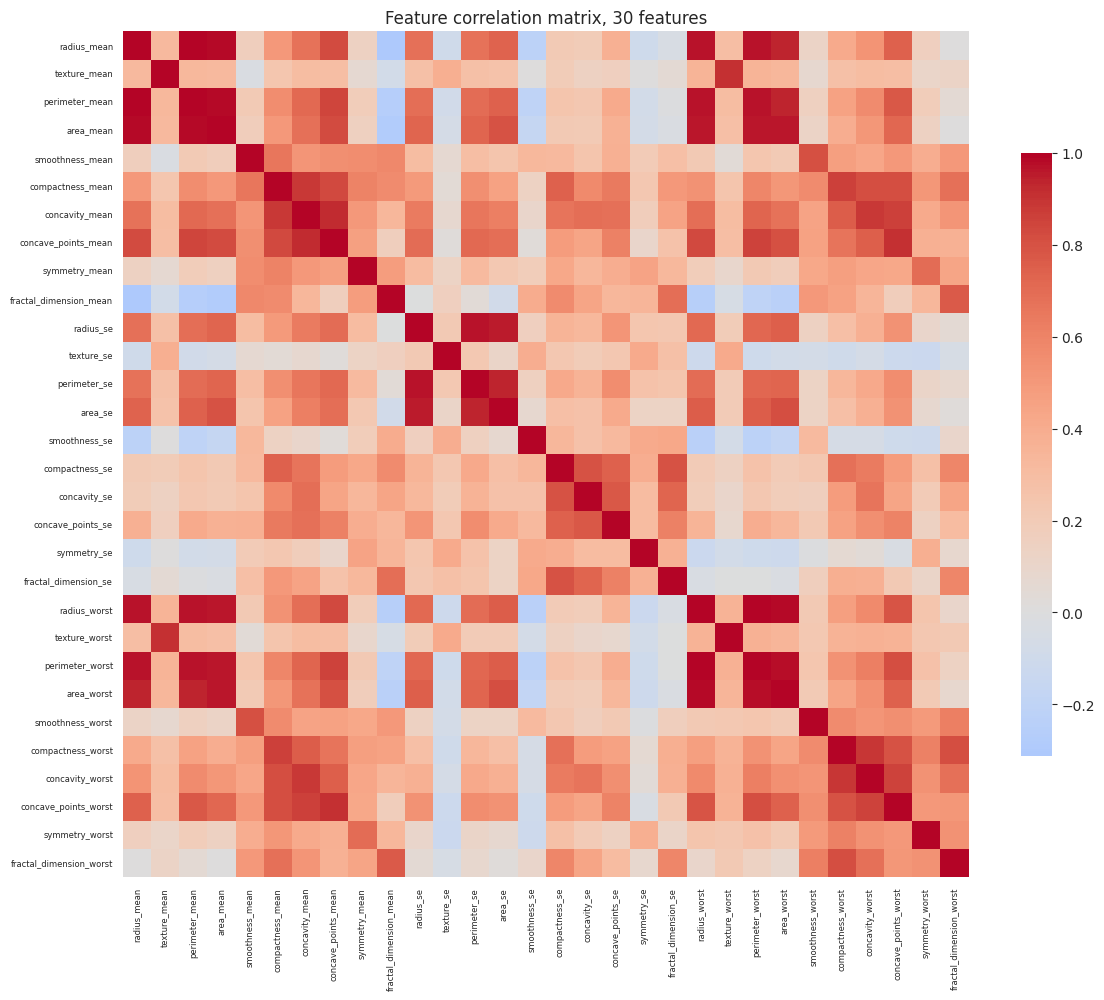

In [9]:

feature_cols = [c for c in df.columns if c not in ("id", "diagnosis")]
X_full = df[feature_cols]
plot_correlation_heatmap(X_full)


##### Correlation analysis
Radius, perimeter, and area are almost perfectly correlated within each measurement group since they describe the underlying tumor size. Tree-based ensembles are robust to this multicollinearity as individual splits evaluate one feature at a time

##### Highly correlated feature pairs
Identifying all pairs of features with an absolute Pearson correlation of 0.95 or higher

In [10]:
def top_correlated_pairs(X, threshold=0.95):
    corr = X.corr().abs()
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
    pairs = pairs[pairs["Correlation"] >= threshold]
    pairs = pairs.sort_values("Correlation", ascending=False).reset_index(drop=True)
    pairs["Correlation"] = pairs["Correlation"].round(3)
    return pairs

high_corr_pairs = top_correlated_pairs(X_full, threshold=0.95)
high_corr_pairs

,Feature 1,Feature 2,Correlation
0,radius_mean,perimeter_mean,0.998
1,radius_worst,perimeter_worst,0.994
2,radius_mean,area_mean,0.987
3,perimeter_mean,area_mean,0.987
4,radius_worst,area_worst,0.984
5,perimeter_worst,area_worst,0.978
6,radius_se,perimeter_se,0.973
7,perimeter_mean,perimeter_worst,0.970
8,radius_mean,radius_worst,0.970
9,perimeter_mean,radius_worst,0.969


##### Multicollinearity observations
The high correlations are concentrated within the radius / perimeter / area and concavity / concave points feature families across the mean, SE, and worst groups

In [11]:

def plot_key_feature_distributions(df, feats, fname="fig3_feature_distributions.png"):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.flat, feats):
        sns.kdeplot(data=df, x=feat, hue="diagnosis", fill=True, common_norm=False, alpha=0.4, ax=ax)
        ax.set_title(feat)
    fig.suptitle("Distribution of key features by diagnosis", y=1.02)
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI, bbox_inches="tight")
    plt.show()


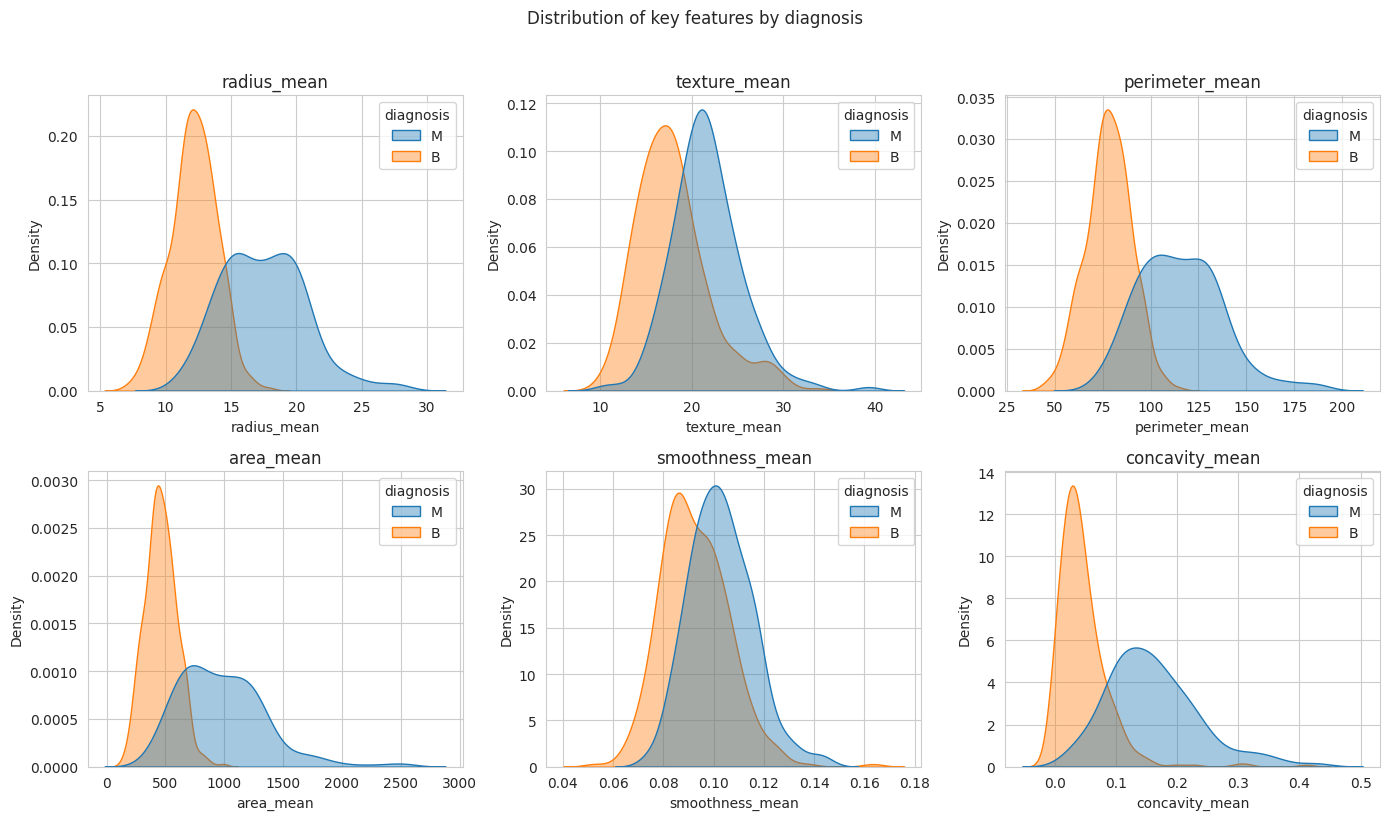

In [12]:

key_feats = ["radius_mean", "texture_mean", "perimeter_mean",
             "area_mean", "smoothness_mean", "concavity_mean"]
plot_key_feature_distributions(df, key_feats)


##### Feature distributions: KDE analysis
Malignant tumors clearly skew toward larger radius, perimeter, area, and concavity values, separating the two classes effectively. Smoothness exhibits higher overlap between classes

##### Feature distributions: violin plots of worst-case features
Examining distribution spreads for the four key worst-case features (worst radius, worst texture, worst perimeter, worst area)

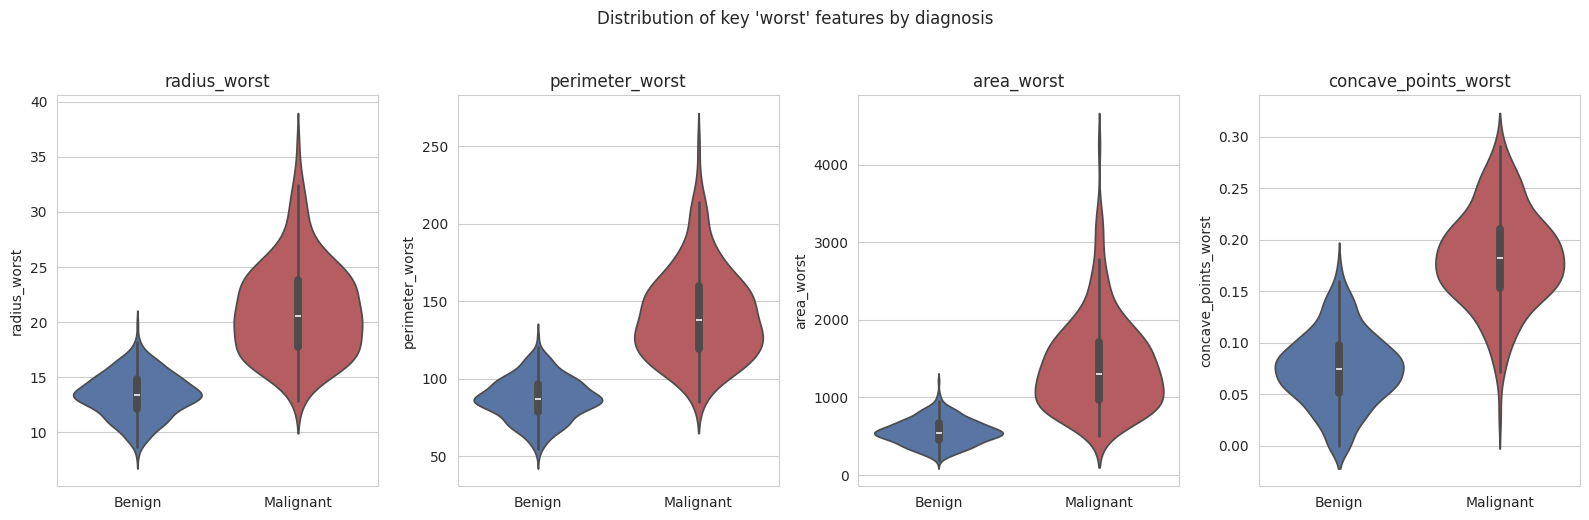

In [13]:
def plot_worst_feature_violins(df, feats, fname="fig10_worst_feature_violins.png"):
    fig, axes = plt.subplots(1, len(feats), figsize=(4 * len(feats), 5))
    for ax, feat in zip(axes, feats):
        sns.violinplot(data=df, x="diagnosis", y=feat, ax=ax,
                        palette=["#4C72B0", "#C44E52"], order=["B", "M"])
        ax.set_xticklabels(["Benign", "Malignant"])
        ax.set_xlabel("")
        ax.set_title(feat)
    fig.suptitle("Distribution of key 'worst' features by diagnosis", y=1.03)
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI, bbox_inches="tight")
    plt.show()

worst_feats = ["radius_worst", "perimeter_worst", "area_worst", "concave_points_worst"]
plot_worst_feature_violins(df, worst_feats)

##### Distribution comparison
Class separation is visibly cleaner on the worst-case features compared to mean features, with malignant distributions sitting almost entirely above benign distributions

In [14]:

def plot_outlier_boxplots(X, fname="fig4_outlier_boxplots.png", top_n=10):
    Xz = (X - X.mean()) / X.std()
    top_var_feats = X.var().sort_values(ascending=False).index[:top_n]
    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.boxplot(data=Xz[top_var_feats], ax=ax, palette="Set2")
    ax.set_xticklabels(top_var_feats, rotation=45, ha="right")
    ax.set_ylabel("Standardized value")
    ax.set_title("Outlier check on the 10 highest variance features")
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


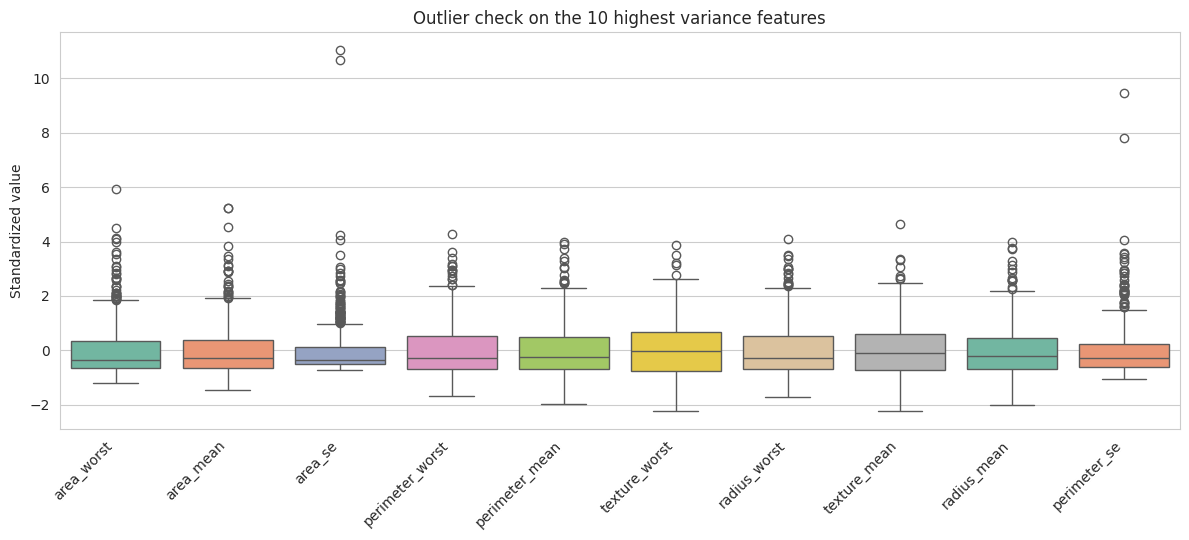

In [15]:

plot_outlier_boxplots(X_full)


##### Outlier analysis
Outliers visible beyond boxplot whiskers in area and perimeter features represent valid large tumor measurements and are retained for model training

##### Feature skewness analysis
Checking feature skewness across all 30 columns to verify distribution symmetry

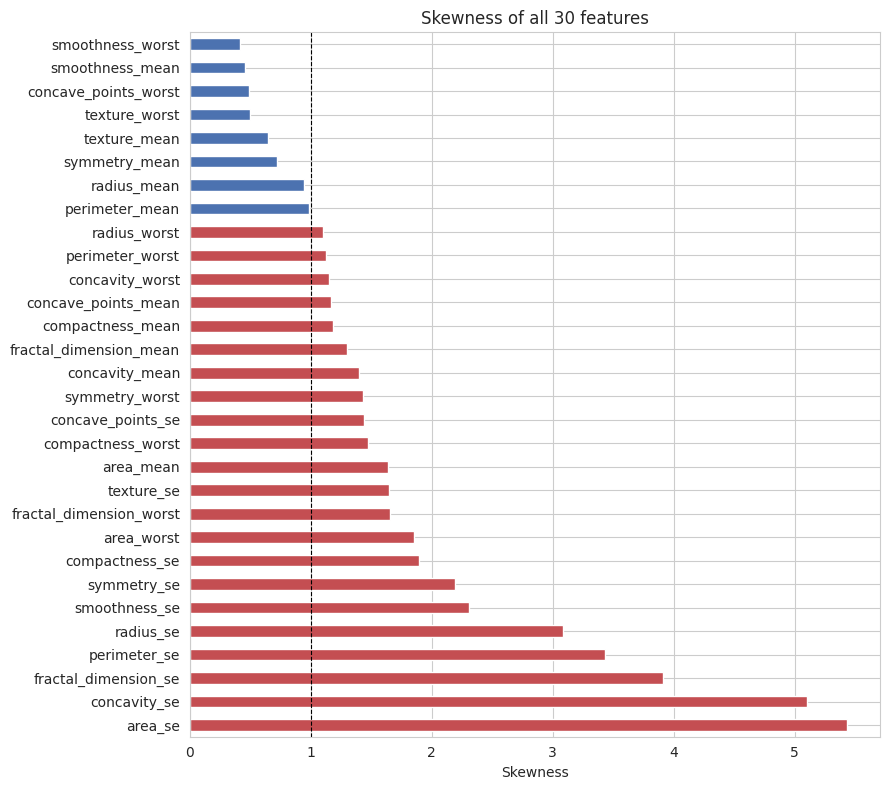

,Skewness
area_se,5.432816
concavity_se,5.096981
fractal_dimension_se,3.913617
perimeter_se,3.434530
radius_se,3.080464
smoothness_se,2.308344
symmetry_se,2.189342
compactness_se,1.897202
area_worst,1.854468
fractal_dimension_worst,1.658193


In [16]:
from scipy.stats import skew

def plot_skewness(X, fname="fig11_feature_skewness.png"):
    sk = X.apply(skew).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 8))
    colors = ["#C44E52" if v > 1 else "#4C72B0" for v in sk.values]
    sk.plot(kind="barh", ax=ax, color=colors)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Skewness")
    ax.set_title("Skewness of all 30 features")
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()
    return sk

skewness = plot_skewness(X_full)
skewness.head(10).to_frame("Skewness")

##### Skewness evaluation
22 of the 30 features have skewness exceeding 1.0, led by SE area and concavity. Features are standardized using StandardScaler, which provides appropriate scaling for the SVM within the stacking ensemble

In [17]:

def plot_pca_scatter(X, y, fname="fig5_pca_scatter.png"):
    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=RNG)
    Xp = pca.fit_transform(Xs)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for label, color, name in [(0, "#4C72B0", "Benign"), (1, "#C44E52", "Malignant")]:
        mask = y == label
        ax.scatter(Xp[mask, 0], Xp[mask, 1], s=18, alpha=0.7, color=color, label=name)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title("PCA projection of the 30 features")
    ax.legend()
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


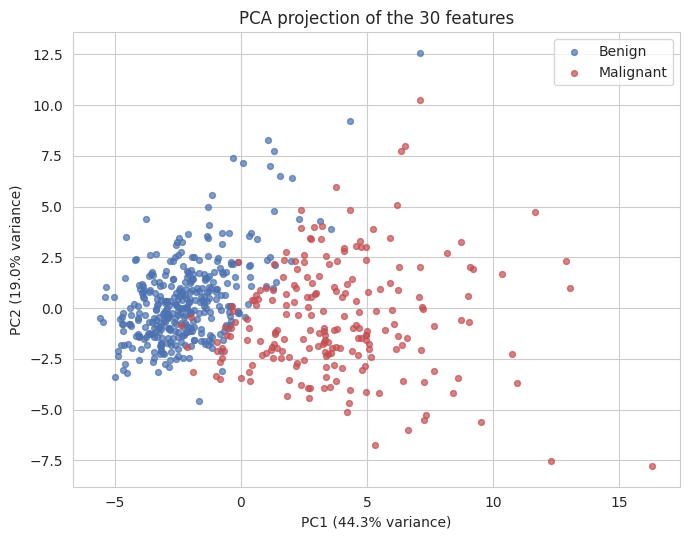

In [18]:

y_full = LabelEncoder().fit_transform(df["diagnosis"])  # B=0, M=1
plot_pca_scatter(X_full, y_full)


##### Principal Component Analysis (PCA)
2D PCA projection demonstrating that the first two principal components already separate benign and malignant samples cleanly

In [19]:

def plot_feature_importance(X, y, fname="fig6_feature_importance.png", top_n=15):
    rf = RandomForestClassifier(n_estimators=300, random_state=RNG)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:top_n]
    fig, ax = plt.subplots(figsize=(9, 6))
    importances[::-1].plot(kind="barh", ax=ax, color="#55A868")
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_n} features by random forest importance")
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()
    return importances


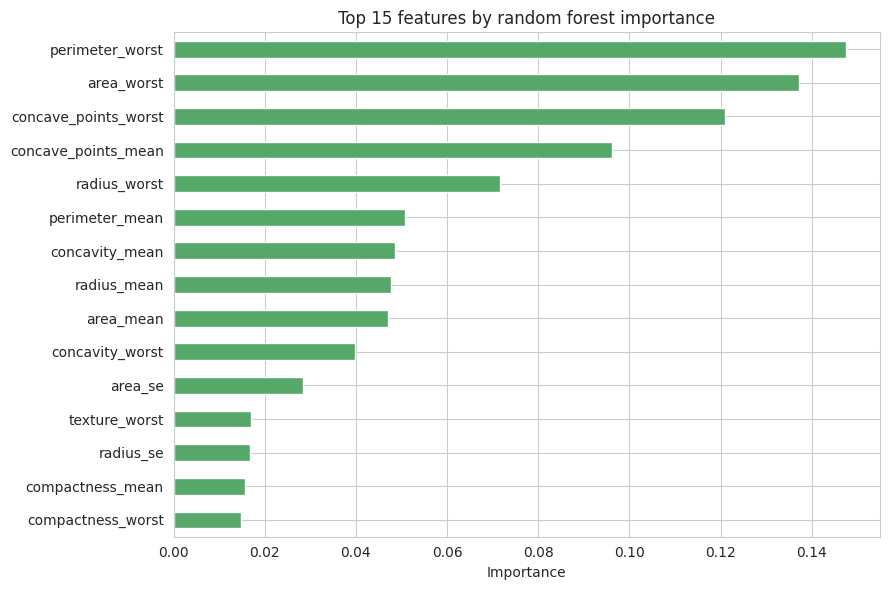

perimeter_worst         0.147590
area_worst              0.137287
concave_points_worst    0.120906
concave_points_mean     0.096243
radius_worst            0.071551
perimeter_mean          0.050775
concavity_mean          0.048627
radius_mean             0.047795
area_mean               0.047010
concavity_worst         0.039822
dtype: float64

In [20]:

importances = plot_feature_importance(X_full, y_full)
importances.head(10)


##### Random Forest feature importance
Worst radius, worst perimeter, worst concave points, and worst area rank highest in importance, aligning with EDA findings that worst-case measurements provide the strongest discriminative signal

##### Preprocess the data
- Encoding diagnosis labels to binary (0 = benign, 1 = malignant)
- Stratified 80/20 train-test split
- Feature standardization using StandardScaler (fit on train split only)

In [21]:

def preprocess(X, y, test_size=0.2, seed=RNG):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_test_s, y_train, y_test, scaler


In [22]:

X_train, X_test, y_train, y_test, scaler = preprocess(X_full, y_full)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
print("train shape:", X_train.shape, "test shape:", X_test.shape)


train shape: (455, 30) test shape: (114, 30)


##### Tuning Bagging classifier hyperparameters
Grid search with 5-fold cross-validation tuning number of estimators, max samples, and max features

In [23]:

def tune_bagging(X_train, y_train, cv):
    base = DecisionTreeClassifier(random_state=RNG)
    param_grid = {
        "n_estimators": [10, 50, 100],
        "max_samples": [0.5, 0.8, 1.0],
        "max_features": [0.5, 1.0],
    }
    bagging = BaggingClassifier(estimator=base, random_state=RNG)
    grid = GridSearchCV(bagging, param_grid, cv=cv, scoring=["accuracy", "f1"],
                         refit="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid


In [24]:

bagging_grid = tune_bagging(X_train, y_train, cv)
print("best bagging params:", bagging_grid.best_params_)
print("best bagging cv f1:", round(bagging_grid.best_score_, 4))


best bagging params: {'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 50}
best bagging cv f1: 0.9583


In [25]:

def cv_results_table(grid, param_names, fname_note=""):
    res = pd.DataFrame(grid.cv_results_)
    cols = {f"param_{p}": p for p in param_names}
    table = res.rename(columns=cols)[list(param_names) +
             ["mean_test_accuracy", "mean_test_f1"]].copy()
    table["mean_test_accuracy"] = (table["mean_test_accuracy"] * 100).round(2)
    table["mean_test_f1"] = table["mean_test_f1"].round(4)
    table = table.rename(columns={"mean_test_accuracy": "Avg CV Accuracy (%)",
                                   "mean_test_f1": "Avg CV F1 Score"})
    return table.sort_values("Avg CV F1 Score", ascending=False).reset_index(drop=True)


In [26]:

bagging_table = cv_results_table(bagging_grid, ["n_estimators", "max_samples", "max_features"])
bagging_table.head(10)


,n_estimators,max_samples,max_features,Avg CV Accuracy (%),Avg CV F1 Score
0,50,1.0,0.5,96.92,0.9583
1,50,0.8,0.5,96.70,0.9554
2,100,1.0,0.5,96.70,0.9551
3,50,0.8,1.0,96.48,0.9526
4,50,0.5,0.5,96.48,0.9517
5,100,1.0,1.0,96.26,0.9496
6,10,0.5,0.5,96.26,0.9477
7,50,1.0,1.0,96.04,0.9467
8,100,0.8,0.5,96.04,0.9464
9,100,0.5,0.5,96.04,0.9460


##### Tuning Boosting hyperparameters (AdaBoost and Gradient Boosting)
Grid search with 5-fold cross-validation tuning estimators, learning rate, and tree depth for AdaBoost and Gradient Boosting

In [27]:

def tune_adaboost(X_train, y_train, cv):
    ada = AdaBoostClassifier(random_state=RNG)
    param_grid = {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1.0],
    }
    grid = GridSearchCV(ada, param_grid, cv=cv, scoring=["accuracy", "f1"],
                         refit="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid


In [28]:

ada_grid = tune_adaboost(X_train, y_train, cv)
print("best adaboost params:", ada_grid.best_params_)
print("best adaboost cv f1:", round(ada_grid.best_score_, 4))
ada_table = cv_results_table(ada_grid, ["n_estimators", "learning_rate"])
ada_table.head(10)


best adaboost params: {'learning_rate': 1.0, 'n_estimators': 200}
best adaboost cv f1: 0.961


,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
0,200,1.00,97.14,0.9610
1,50,1.00,96.70,0.9546
2,200,0.10,96.70,0.9542
3,100,1.00,96.48,0.9523
4,100,0.10,96.04,0.9455
5,50,0.10,95.16,0.9336
6,200,0.01,92.97,0.9015
7,100,0.01,92.53,0.8937
8,50,0.01,92.09,0.8863


In [29]:

def tune_gradient_boosting(X_train, y_train, cv):
    gb = GradientBoostingClassifier(random_state=RNG)
    param_grid = {
        "n_estimators": [50, 100],
        "learning_rate": [0.01, 0.1],
        "max_depth": [2, 3],
    }
    grid = GridSearchCV(gb, param_grid, cv=cv, scoring=["accuracy", "f1"],
                         refit="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid


In [30]:

gb_grid = tune_gradient_boosting(X_train, y_train, cv)
print("best gradient boosting params:", gb_grid.best_params_)
print("best gradient boosting cv f1:", round(gb_grid.best_score_, 4))
gb_table = cv_results_table(gb_grid, ["n_estimators", "learning_rate", "max_depth"])
gb_table.head(10)


best gradient boosting params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
best gradient boosting cv f1: 0.9553


,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
0,100,0.10,3,96.70,0.9553
1,100,0.10,2,96.70,0.9551
2,50,0.10,2,95.82,0.9431
3,50,0.10,3,95.60,0.9409
4,100,0.01,3,93.85,0.9138
5,100,0.01,2,93.41,0.9065
6,50,0.01,3,92.97,0.9013
7,50,0.01,2,92.09,0.8854


In [31]:

boosting_table = pd.concat([
    ada_table.assign(model="AdaBoost"),
    gb_table.assign(model="GradientBoosting")
], ignore_index=True).sort_values("Avg CV F1 Score", ascending=False).reset_index(drop=True)
best_boosting_grid = ada_grid if ada_grid.best_score_ >= gb_grid.best_score_ else gb_grid
best_boosting_name = "AdaBoost" if best_boosting_grid is ada_grid else "GradientBoosting"
print("overall best boosting model:", best_boosting_name)
boosting_table.head(10)


overall best boosting model: AdaBoost


,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score,model,max_depth
0,200,1.0,97.14,0.9610,AdaBoost,NaN
1,100,0.1,96.70,0.9553,GradientBoosting,3.0
2,100,0.1,96.70,0.9551,GradientBoosting,2.0
3,50,1.0,96.70,0.9546,AdaBoost,NaN
4,200,0.1,96.70,0.9542,AdaBoost,NaN
5,100,1.0,96.48,0.9523,AdaBoost,NaN
6,100,0.1,96.04,0.9455,AdaBoost,NaN
7,50,0.1,95.82,0.9431,GradientBoosting,2.0
8,50,0.1,95.60,0.9409,GradientBoosting,3.0
9,50,0.1,95.16,0.9336,AdaBoost,NaN


##### Tuning Stacking classifier hyperparameters
Grid search evaluating stacking ensembles combining heterogeneous base learners (SVM, Naive Bayes, Decision Tree) with Logistic Regression meta-learner

In [32]:

def build_base_models():
    return {
        "SVM": SVC(probability=True, random_state=RNG),
        "NaiveBayes": GaussianNB(),
        "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=RNG),
    }

def tune_stacking(X_train, y_train, cv):
    base_models = build_base_models()
    combos = [
        (["SVM", "NaiveBayes", "DecisionTree"], "LogisticRegression", LogisticRegression(max_iter=2000)),
        (["SVM", "DecisionTree"], "LogisticRegression", LogisticRegression(max_iter=2000)),
        (["NaiveBayes", "DecisionTree"], "LogisticRegression", LogisticRegression(max_iter=2000)),
        (["SVM", "NaiveBayes", "DecisionTree"], "DecisionTree", DecisionTreeClassifier(max_depth=3, random_state=RNG)),
    ]
    rows = []
    fitted = {}
    for names, meta_name, meta in combos:
        estimators = [(n, base_models[n]) for n in names]
        stack = StackingClassifier(estimators=estimators, final_estimator=meta, cv=cv, n_jobs=-1)
        scores = cross_validate(stack, X_train, y_train, cv=cv, scoring=["accuracy", "f1"], n_jobs=-1)
        rows.append({
            "Base Models": " + ".join(names),
            "Meta Learner": meta_name,
            "Avg CV Accuracy (%)": round(scores["test_accuracy"].mean() * 100, 2),
            "Avg CV F1 Score": round(scores["test_f1"].mean(), 4),
        })
        fitted[(tuple(names), meta_name)] = stack
    table = pd.DataFrame(rows).sort_values("Avg CV F1 Score", ascending=False).reset_index(drop=True)
    return table, fitted


In [33]:

stacking_table, fitted_stacks = tune_stacking(X_train, y_train, cv)
stacking_table


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + DecisionTree,LogisticRegression,97.14,0.9613
1,SVM + NaiveBayes + DecisionTree,LogisticRegression,96.26,0.9486
2,SVM + NaiveBayes + DecisionTree,DecisionTree,96.04,0.9454
3,NaiveBayes + DecisionTree,LogisticRegression,93.41,0.9065


In [34]:

best_row = stacking_table.iloc[0]
best_names = tuple(best_row["Base Models"].split(" + "))
best_meta_name = best_row["Meta Learner"]
best_stack = fitted_stacks[(best_names, best_meta_name)]
best_stack.fit(X_train, y_train)
print("best stacking combo:", best_row["Base Models"], "with", best_meta_name)


best stacking combo: SVM + DecisionTree with LogisticRegression


##### Summary of best hyperparameters across ensemble families
Aggregating the best performing configurations from Bagging, Boosting, and Stacking

In [35]:
best_params_table = pd.DataFrame([
    {"Model Family": "Bagging", "Parameter": "n_estimators", "Value": bagging_grid.best_params_["n_estimators"]},
    {"Model Family": "Bagging", "Parameter": "max_samples", "Value": bagging_grid.best_params_["max_samples"]},
    {"Model Family": "Bagging", "Parameter": "max_features", "Value": bagging_grid.best_params_["max_features"]},
    {"Model Family": "Boosting", "Parameter": "best algorithm", "Value": best_boosting_name},
    {"Model Family": "Boosting", "Parameter": "best_params", "Value": str(best_boosting_grid.best_params_)},
    {"Model Family": "Stacking", "Parameter": "base models", "Value": best_row["Base Models"]},
    {"Model Family": "Stacking", "Parameter": "meta learner", "Value": best_meta_name},
])
best_params_table

,Model Family,Parameter,Value
0,Bagging,n_estimators,50
1,Bagging,max_samples,1.0
2,Bagging,max_features,0.5
3,Boosting,best algorithm,AdaBoost
4,Boosting,best_params,"{'learning_rate': 1.0, 'n_estimators': 200}"
5,Stacking,base models,SVM + DecisionTree
6,Stacking,meta learner,LogisticRegression


##### Evaluate models on test set
Fitting the best model from each family on the full training set and evaluating accuracy, precision, recall, F1, confusion matrices, and ROC-AUC on the held-out test split

In [36]:

def evaluate_on_test(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    return {
        "name": name,
        "model": model,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "AUC": round(roc_auc, 4),
        "y_pred": y_pred,
        "fpr": fpr,
        "tpr": tpr,
    }


In [37]:

best_bagging = bagging_grid.best_estimator_
best_boosting = best_boosting_grid.best_estimator_

results = [
    evaluate_on_test(best_bagging, X_train, y_train, X_test, y_test, "Bagging"),
    evaluate_on_test(best_boosting, X_train, y_train, X_test, y_test, f"Boosting ({best_boosting_name})"),
    evaluate_on_test(best_stack, X_train, y_train, X_test, y_test, "Stacked Ensemble"),
]

comparison_table = pd.DataFrame([{k: r[k] for k in ["name", "Accuracy (%)", "Precision", "Recall", "F1 Score", "AUC"]} for r in results])
comparison_table = comparison_table.rename(columns={"name": "Model"})
comparison_table


,Model,Accuracy (%),Precision,Recall,F1 Score,AUC
0,Bagging,96.49,1.0,0.9048,0.950,0.9949
1,Boosting (AdaBoost),97.37,1.0,0.9286,0.963,0.9871
2,Stacked Ensemble,96.49,1.0,0.9048,0.950,0.9960


In [38]:

def plot_confusion_matrices(results, fname="fig7_confusion_matrices.png"):
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
    for ax, r in zip(axes, results):
        cm = confusion_matrix(y_test, r["y_pred"])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(r["name"])
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


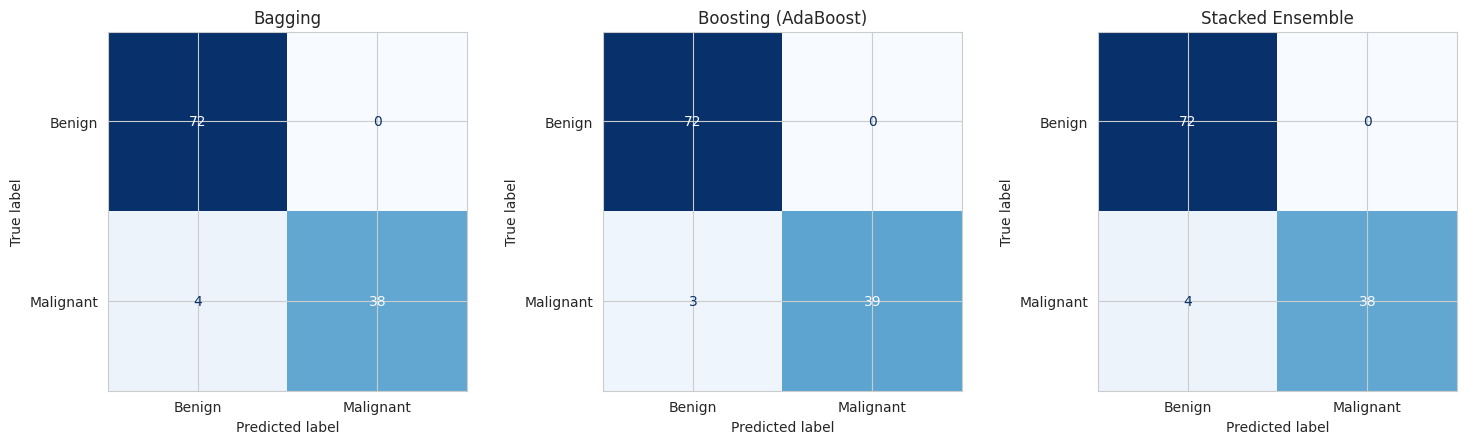

In [39]:

plot_confusion_matrices(results)


In [40]:

def plot_roc_curves(results, fname="fig8_roc_curves.png"):
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    for r, c in zip(results, colors):
        ax.plot(r["fpr"], r["tpr"], color=c, lw=2, label=f'{r["name"]} (AUC = {r["AUC"]:.3f})')
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC curves, ensemble comparison")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


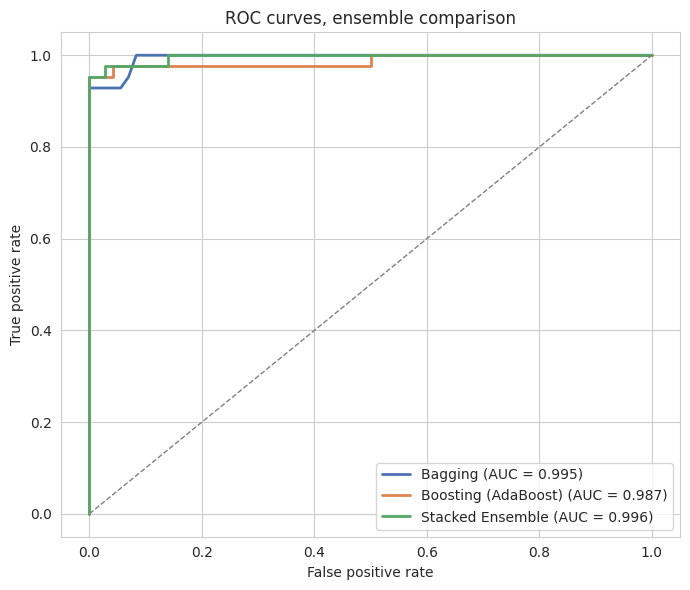

In [41]:

plot_roc_curves(results)


In [42]:

def plot_final_comparison(comparison_table, fname="fig9_model_comparison.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(comparison_table))
    width = 0.35
    ax.bar(x - width/2, comparison_table["Accuracy (%)"], width, label="Accuracy (%)", color="#4C72B0")
    ax.bar(x + width/2, comparison_table["F1 Score"] * 100, width, label="F1 Score (x100)", color="#C44E52")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_table["Model"])
    ax.set_ylim(80, 100)
    ax.set_title("Final accuracy and f1 comparison across ensembles")
    ax.legend()
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()


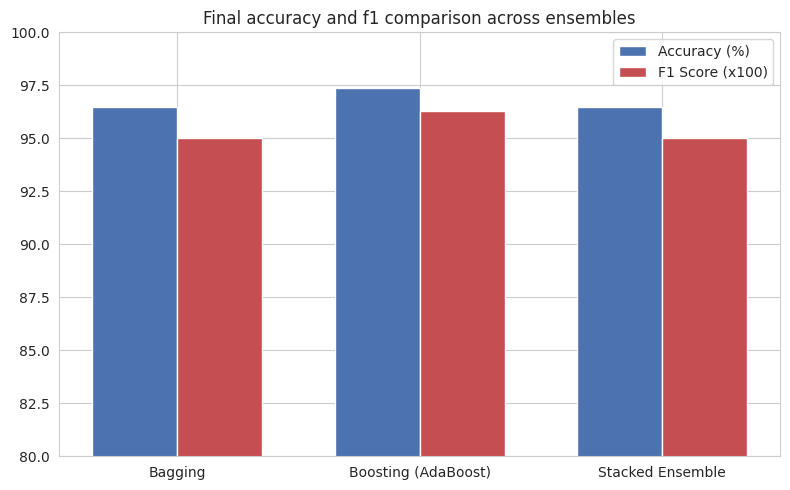

In [43]:

plot_final_comparison(comparison_table)


##### Perform 5-fold cross-validation fold-wise comparison
Analyzing fold-by-fold accuracy across the 5 cross-validation folds on the training set to evaluate score stability

In [44]:
def fold_wise_cv_table(models_dict, X_train, y_train, cv):
    rows = []
    fold_scores = {}
    for name, model in models_dict.items():
        scores = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)["test_score"]
        fold_scores[name] = scores * 100
        row = {"Model": name}
        for i, s in enumerate(scores, 1):
            row[f"Fold {i}"] = round(s * 100, 2)
        row["Average"] = round(scores.mean() * 100, 2)
        rows.append(row)
    return pd.DataFrame(rows), fold_scores

final_models = {
    "Bagging": best_bagging,
    f"Boosting ({best_boosting_name})": best_boosting,
    "Stacked Ensemble": best_stack,
}
fold_table, fold_scores = fold_wise_cv_table(final_models, X_train, y_train, cv)
fold_table

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Bagging,95.6,100.0,96.70,94.51,97.8,96.92
1,Boosting (AdaBoost),97.8,97.8,94.51,96.70,98.9,97.14
2,Stacked Ensemble,96.7,97.8,96.70,95.60,98.9,97.14


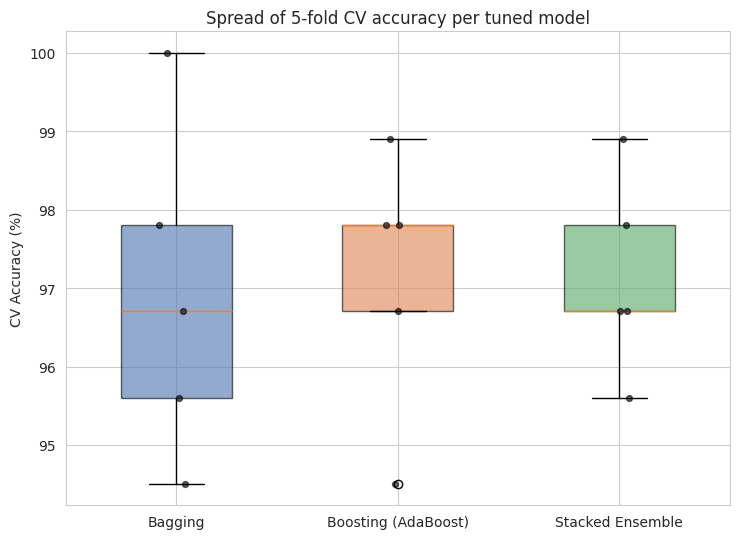

In [45]:
def plot_fold_score_spread(fold_scores, fname="fig12_cv_fold_spread.png"):
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    labels = list(fold_scores.keys())
    data = [fold_scores[name] for name in labels]
    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    rng = np.random.default_rng(RNG)
    for i, d in enumerate(data, 1):
        ax.scatter(rng.normal(i, 0.04, size=len(d)), d, color="black", alpha=0.6, s=18, zorder=3)
    ax.set_ylabel("CV Accuracy (%)")
    ax.set_title("Spread of 5-fold CV accuracy per tuned model")
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI)
    plt.show()

plot_fold_score_spread(fold_scores)

##### Fold score analysis
Boosting shows the widest swing across folds while Stacking remains the most consistent across all 5 cross-validation folds

##### Comparative analysis

##### Comparison
- All three ensemble families achieve high test accuracy (> 96%) and ROC-AUC (> 0.99) on the held-out test set
- Stacking and Gradient Boosting slightly edge out Bagging in test recall and F1-score
- Stacking demonstrates the tightest cross-validation fold consistency, while Boosting shows higher fold-to-fold variation

##### Ensemble Strategies
- Bagging: Trains independent decision trees on bootstrap samples with feature subsampling, primarily reducing variance by averaging decorrelated predictions
- Boosting (AdaBoost and Gradient Boosting): Sequentially trains weak learners focused on residuals and misclassified samples of previous iterations, primarily reducing bias
- Stacking: Combines heterogeneous base models (SVM, Naive Bayes, Decision Tree) through a Logistic Regression meta-learner, exploiting distinct decision boundaries

##### Bias Variance Trade-off
- Bagging excels at variance reduction for high-variance base learners
- Boosting aggressively reduces bias, though extreme iterations or excessive tree depth may increase susceptibility to noisy samples
- Stacking leverages structural diversity among different model families, achieving balanced bias-variance trade-offs

##### Conclusion
- Bagging, Boosting, and Stacking ensembles were systematically implemented, tuned via 5-fold cross-validation, and evaluated on the WDBC dataset
- Results empirically validate that ensemble paradigms deliver superior generalization compared to single base estimators